In [48]:
import pathlib

data_dir = pathlib.Path('./flower_photos')
data_dir

WindowsPath('flower_photos')

In [49]:
# 5개의 폴더가 있고 3670개의 이미지가 존재
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [50]:
image_data = list(data_dir.glob('*/*.jpg'))
image_data[:3]

[WindowsPath('flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('flower_photos/daisy/10172379554_b296050f82_n.jpg')]

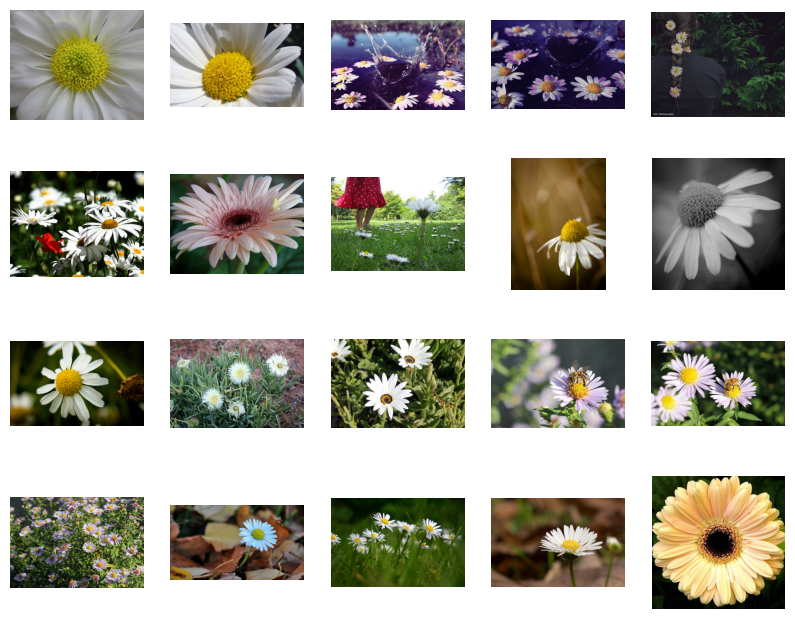

In [51]:
import PIL
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(5, 5, i+1)
    img = PIL.Image.open(image_data[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()


In [52]:
# 훈련세트 읽기

import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    shuffle=True,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [53]:
# 종류 확인 === 폴더명
train_ds.class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

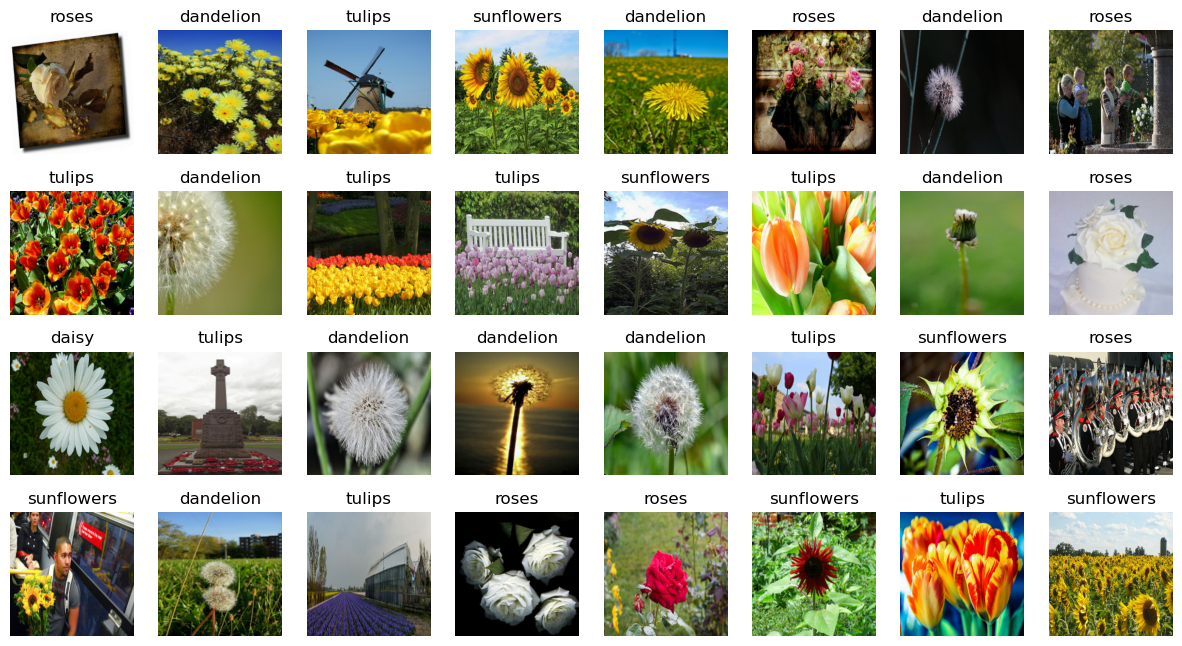

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for images, labels in train_ds.take(1):
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')
plt.show()

In [55]:
# 검증세트 읽기
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    shuffle=False,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


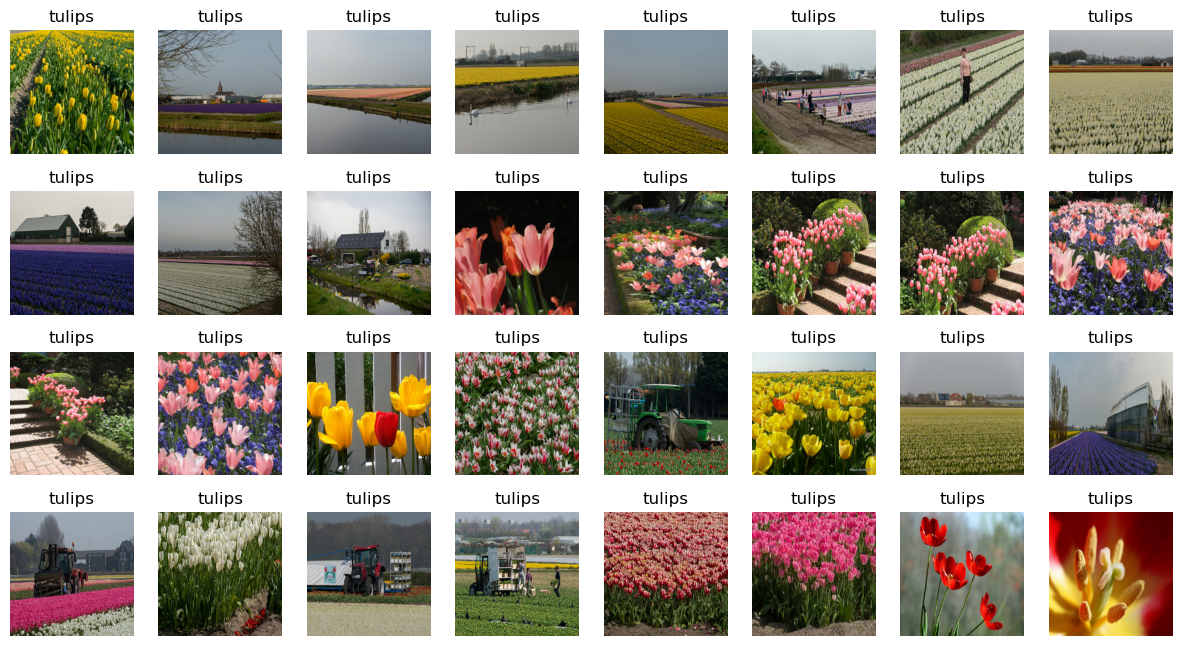

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for images, labels in val_ds.take(1):
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')
plt.show()

In [57]:
# 이미지 (n, 224, 224, 3) === (batch_size, height, width, channels)
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)

(32, 224, 224, 3) (32,)


In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Rescaling, Conv2D, MaxPooling2D

model = Sequential([
    Input(shape=(224, 224, 3)),      # 입력크기 (가로, 높이, 채널)
    Rescaling(1.0/255.0),            # 정규화 스케일 minmax스케일  0~1사이의 숫자로 변환
    # (3 * 3) * 3 * 16 + 16 = 448    # 마지막 16은 각filter에 대한 bias
    Conv2D(filters=16, kernel_size=(3, 3), padding='valid', strides=(1, 1)) , # 합성곱층
    # (3 * 3) * 16 * 32 + 32 = 4640
    Conv2D(filters=32, kernel_size=(3, 3), padding='valid', strides=(1, 1)) , # 합성곱층
    # (224 // 2) * ( 224 // 2) * 32 = 12544
    MaxPooling2D(pool_size=(2, 2)),  # 풀링층
    Flatten(),                       # 평탄화층
    Dense(128, activation='relu'),   # 완전연결층
    Dense(5, activation='softmax'),  # 출력층
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 387200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    49,561,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,567,461 (189.08 MB)

 Trainable params: 49,567,461 (189.08 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [62]:
history = model.fit(train_ds, validation_data=val_ds, epochs=6, verbose=2)

Epoch 1/6


KeyboardInterrupt: 

In [ ]:
# mobilenetv2
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(224, 224, 3))

base_model = keras.applications.MobileNetV2(
    include_top=False,   # 특징 추출기만 가져오기
    weights="imagenet",  # 사전학습 사용
    input_tensor=inputs
)

base_model.trainable = False # 특징추출기 가중치 업데이트 안함.

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

mobile_model = keras.Model(inputs, outputs)

mobile_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobile_model.summary()

In [70]:
history2 = mobile_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=2)

Epoch 1/10
92/92 - 72s - 787ms/step - accuracy: 0.6962 - loss: 0.8139 - val_accuracy: 0.7875 - val_loss: 0.5785
Epoch 2/10
92/92 - 64s - 699ms/step - accuracy: 0.7057 - loss: 0.7739 - val_accuracy: 0.7738 - val_loss: 0.6298
Epoch 3/10
92/92 - 75s - 819ms/step - accuracy: 0.7262 - loss: 0.7336 - val_accuracy: 0.7820 - val_loss: 0.6002
Epoch 4/10
92/92 - 80s - 869ms/step - accuracy: 0.7360 - loss: 0.7101 - val_accuracy: 0.7466 - val_loss: 0.6932
Epoch 5/10
92/92 - 58s - 634ms/step - accuracy: 0.7405 - loss: 0.6947 - val_accuracy: 0.8651 - val_loss: 0.3810
Epoch 6/10
92/92 - 67s - 733ms/step - accuracy: 0.7554 - loss: 0.6374 - val_accuracy: 0.6894 - val_loss: 0.8461
Epoch 7/10
92/92 - 62s - 673ms/step - accuracy: 0.7711 - loss: 0.6221 - val_accuracy: 0.8338 - val_loss: 0.4757
Epoch 8/10
92/92 - 49s - 534ms/step - accuracy: 0.7933 - loss: 0.5745 - val_accuracy: 0.7589 - val_loss: 0.6125
Epoch 9/10
92/92 - 65s - 711ms/step - accuracy: 0.8079 - loss: 0.5207 - val_accuracy: 0.8038 - val_loss:

In [71]:
history3 = mobile_model.fit(train_ds, validation_data=val_ds, epochs=3, verbose=2)

Epoch 1/3
92/92 - 32s - 349ms/step - accuracy: 0.8171 - loss: 0.5078 - val_accuracy: 0.8215 - val_loss: 0.5075
Epoch 2/3
92/92 - 48s - 526ms/step - accuracy: 0.8389 - loss: 0.4599 - val_accuracy: 0.7670 - val_loss: 0.6790
Epoch 3/3
92/92 - 81s - 875ms/step - accuracy: 0.8416 - loss: 0.4544 - val_accuracy: 0.8324 - val_loss: 0.4844


In [ ]:
combined_history = {}
# Loop through keys and extend the lists
for key in history1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         .history.keys():
    combined_history[key] = history1.history[key] + history2.history[key]

In [79]:
from tensorflow.keras.models import load_model

model = load_model('./pkl/20260601_flower_efficientnetv2.keras')

In [81]:
model.evaluate(val_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step - accuracy: 0.9877 - loss: 0.0784


[0.07836002856492996, 0.9877384305000305]

# Continue from previous model
---

In [3]:
from tensorflow.keras.models import load_model

model = load_model('./pkl/20260601_flower_efficientnetv2.keras')
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,906,977 (26.35 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 658,444 (2.51 MB)

In [4]:
import pathlib

data_dir = pathlib.Path('./flower_photos')
data_dir

WindowsPath('flower_photos')

In [5]:
# 훈련세트 읽기

import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    shuffle=True,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [6]:
# 검증세트 읽기
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    shuffle=False,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [7]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=2)

Epoch 1/5
92/92 - 43s - 465ms/step - accuracy: 0.9973 - loss: 0.0126 - val_accuracy: 0.9850 - val_loss: 0.0913
Epoch 2/5
92/92 - 37s - 402ms/step - accuracy: 0.9976 - loss: 0.0122 - val_accuracy: 0.9837 - val_loss: 0.0999
Epoch 3/5
92/92 - 39s - 423ms/step - accuracy: 0.9939 - loss: 0.0201 - val_accuracy: 0.9877 - val_loss: 0.0698
Epoch 4/5
92/92 - 40s - 430ms/step - accuracy: 0.9915 - loss: 0.0214 - val_accuracy: 0.9891 - val_loss: 0.0770
Epoch 5/5
92/92 - 40s - 433ms/step - accuracy: 0.9966 - loss: 0.0147 - val_accuracy: 0.9837 - val_loss: 0.0824


In [8]:
model.save('./pkl/20260602_flower_efficientnetv2b0.keras')